# Baseline Model: CatBoostRegressor
## Combined Datasets vs. Immunological Dataset
## Using Immunological T2-T1-Difference Features vs. T2 Immunological Features 


In [1]:
import sys, os
sys.path.insert(0, '../src')
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from skrub import TableReport
import joblib, os
import preprocess
import explore
import model
from sklearn.preprocessing import PowerTransformer

os.environ['PYTHONWARNINGS'] = 'ignore'
MODEL_DIR = os.path.abspath('../models/baseline')


In [2]:
# Running through preprocessing steps
# Load raw data
df_im, df_cl = explore.load_data()

# Clean datasets
im_id_cols = ['Patient', 'Timepoint', 'Date']
df_im_vis   = preprocess.clean_im(df_im, False)
df_cl_vis   = preprocess.clean_cl(df_cl, False)

# Immunological: drop >25% NaN columns, remove confirmed outliers
df_im_mod    = preprocess.remove_nan_cols(df_im_vis, verbose=False)
df_im_mod    = preprocess.remove_outlier_observations(df_im_mod, verbose=False)
df_im_mod    = preprocess.remove_for_modeling(df_im_mod, verbose=False)
# Clinical
df_cl_mod    = preprocess.remove_nan_cols(df_cl_vis, verbose=False)
df_cl_mod    = preprocess.remove_outlier_observations(df_cl_mod, verbose=False)
df_cl_mod    = preprocess.remove_for_modeling(df_cl_mod, verbose=False)

print(f"df_im_mod : {df_im_mod.shape}")
print(f"df_cl_mod : {df_cl_mod.shape}")


df_im_mod : (814, 77)
df_cl_mod : (836, 26)


In [3]:
# Constructing targets:
print('\nConstructing regression targets from clinical data')
pain_targets       = model.construct_datasets_targets(df_cl_mod, 'pain_scale',      [1, 2])
targets_under_load = model.construct_datasets_targets(df_cl_mod, 'pain_under_load', [1, 2])

pt = PowerTransformer(method='yeo-johnson', standardize=True)


Constructing regression targets from clinical data

  Target distributions:
    pain_reduction                              mean=1.382  std=2.061  [-4.000, 7.100]
    pain_reduction_pct                          mean=19.720  std=33.059  [-100.000, 87.654]

  Target distributions:
    pain_under_load_reduction                   mean=0.530  std=0.730  [-1.000, 3.000]
    pain_under_load_reduction_pct               mean=13.610  std=19.750  [-50.000, 75.000]


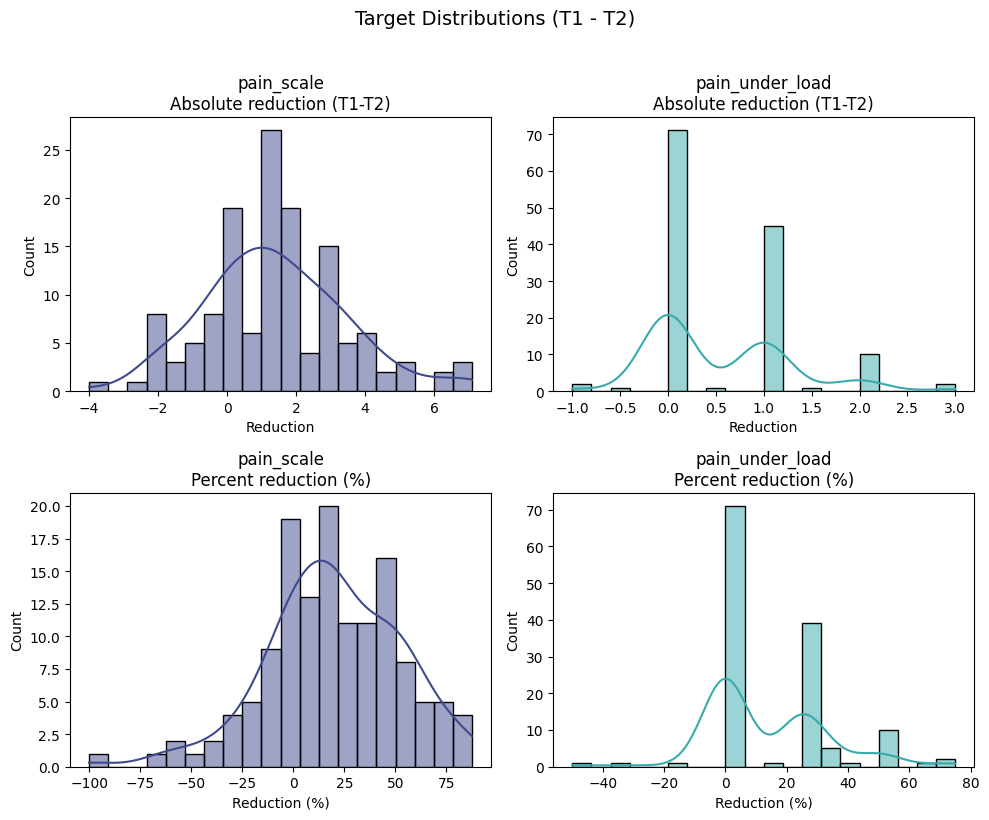

In [4]:
# Plotting target distributions:
target_frames = {
    'pain_scale':      pain_targets,
    'pain_under_load': targets_under_load,
}

fig, axes = plt.subplots(2, len(target_frames), figsize=(5 * len(target_frames), 8))
colors = sns.color_palette('mako', len(target_frames))

for col_idx, (name, tdf) in enumerate(target_frames.items()):
    prefix  = name.replace('_scale', '')   # matches construct_datasets_targets naming
    red_col = f'{prefix}_reduction'
    pct_col = f'{prefix}_reduction_pct'

    # Absolute reduction
    ax0 = axes[0, col_idx]
    sns.histplot(tdf[red_col].dropna(), kde=True, ax=ax0,
                 color=colors[col_idx], bins=20)
    ax0.set_title(f'{name}\nAbsolute reduction (T1-T2)')
    ax0.set_xlabel('Reduction')

    # Percent reduction
    ax1 = axes[1, col_idx]
    sns.histplot(tdf[pct_col].dropna(), kde=True, ax=ax1,
                 color=colors[col_idx], bins=20)
    ax1.set_title(f'{name}\nPercent reduction (%)')
    ax1.set_xlabel('Reduction (%)')

plt.suptitle('Target Distributions (T1 - T2)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


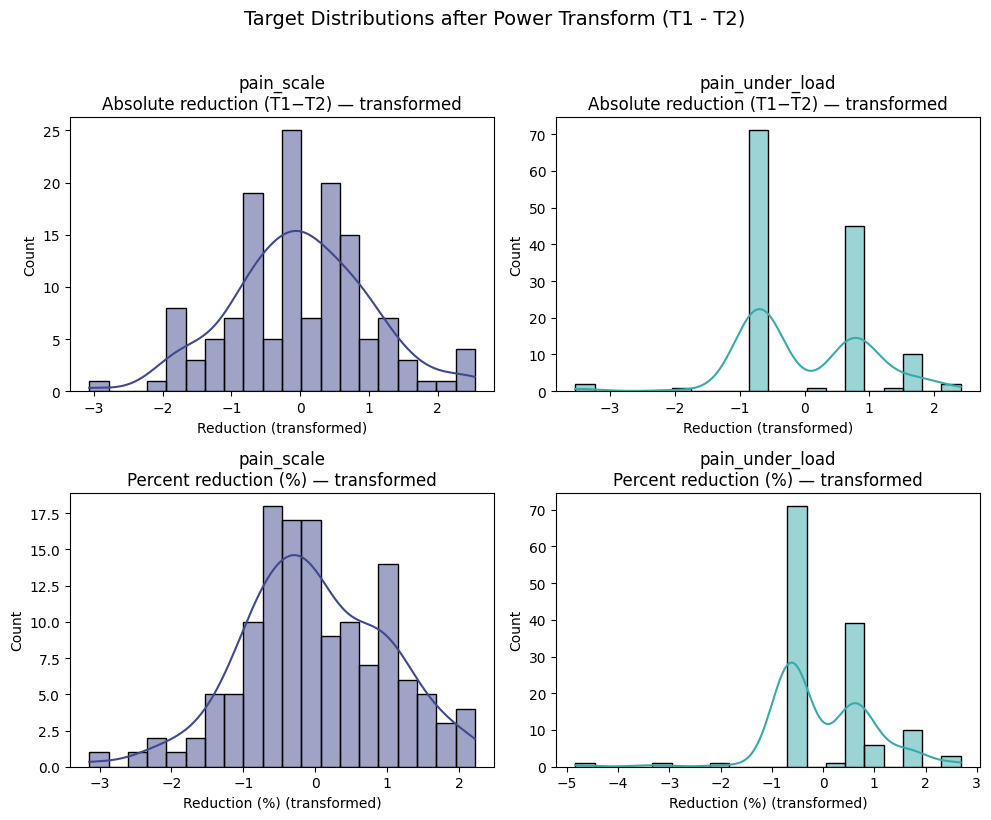

In [5]:
# Visualizing power-transformed target distributions (on copies)
fig, axes = plt.subplots(2, len(target_frames), figsize=(5 * len(target_frames), 8))
colors = sns.color_palette('mako', len(target_frames))

for col_idx, (name, tdf) in enumerate(target_frames.items()):
    prefix  = name.replace('_scale', '')
    red_col = f'{prefix}_reduction'
    pct_col = f'{prefix}_reduction_pct'

    tdf_viz = tdf[[red_col, pct_col]].copy()
    pt_viz  = PowerTransformer(method='yeo-johnson', standardize=True)
    tdf_viz[[red_col, pct_col]] = pt_viz.fit_transform(tdf_viz)

    ax0 = axes[0, col_idx]
    sns.histplot(tdf_viz[red_col].dropna(), kde=True, ax=ax0,
                 color=colors[col_idx], bins=20)
    ax0.set_title(f'{name}\nAbsolute reduction (T1−T2) — transformed')
    ax0.set_xlabel('Reduction (transformed)')

    ax1 = axes[1, col_idx]
    sns.histplot(tdf_viz[pct_col].dropna(), kde=True, ax=ax1,
                 color=colors[col_idx], bins=20)
    ax1.set_title(f'{name}\nPercent reduction (%) — transformed')
    ax1.set_xlabel('Reduction (%) (transformed)')

plt.suptitle('Target Distributions after Power Transform (T1 - T2)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


# ____________________________________________________________
# Using T2-T1 Immunological Difference Features

In [5]:
print('\nConstructing datasets for modeling:')
# Construct model datasets for each target type:
_unique_targets = {
    'pain_reduction':            pain_targets,
    'pain_under_load_reduction': targets_under_load,
}
model_datasets = {}
model_datasets_im = {}

for tgt, tdf in _unique_targets.items():
    model_datasets[tgt] = model.create_model_datasets(
         df_im_mod, df_cl_mod, tdf, timepoints=[1, 2])
    model_datasets_im[tgt] = model.create_model_datasets(                       # immu dataset alone + targets
         df_im_mod, None, tdf, timepoints=[1, 2], single_dataset=True)
    
model_datasets['pain_reduction_pct'] = model_datasets['pain_reduction']
model_datasets['pain_under_load_reduction_pct'] = model_datasets['pain_under_load_reduction']

model_datasets_im['pain_reduction_pct'] = model_datasets_im['pain_reduction']
model_datasets_im['pain_under_load_reduction_pct'] = model_datasets_im['pain_under_load_reduction']


Constructing datasets for modeling:

Modeling dataset ready: T1–T2 difference features + clinical features
Shape: (116, 95),  Patients: 116

Modeling dataset ready: T1–T2 difference features
Shape: (116, 78),  Patients: 116

Modeling dataset ready: T1–T2 difference features + clinical features
Shape: (115, 95),  Patients: 115

Modeling dataset ready: T1–T2 difference features
Shape: (115, 78),  Patients: 115


In [2]:
# Combined dataset with pain scale targets
# Censored from github
#TableReport(model_datasets['pain_reduction_pct'], max_plot_columns=180)

## Correlations Between T2-T1 im. Features and Targets

In [6]:
for tgt, df in model_datasets.items():
    corr = explore.target_correlation(df, tgt, im_id_cols, name='Im. T2-T1 Diff Features', plot=False)


Target Correlation (Im. T2-T1 Diff Features)    Target: pain_reduction

Positive Correlations with pain_reduction (> 0.05):
  Feature                                       Method      Correlation
  -----------------------------------------------------------------
  pain_reduction_pct                            Spearman         0.9753
  T8lo_t2_minus_t1                              Spearman         0.1510
  Tc/Treg_t2_minus_t1                           Spearman         0.1487
  Eosinophils_t2_minus_t1                       Spearman         0.1198
  NKT_16+_t2_minus_t1                           Spearman         0.1163
  age_at_start                                  Spearman         0.1135
  Mo3_t2_minus_t1                               Spearman         0.1129
  Neu_HLADR+_t2_minus_t1                        Spearman         0.1129
  Basophils_t2_minus_t1                         Spearman         0.1074
  TH_CD69+_t2_minus_t1                          Spearman         0.1034
  DPT_t2_minus_

In [8]:
importlib.reload(model)
print('\n Baseline CatBoost on Combined T1-T2 dataset — pain_reduction, pain_reduction_pct,  ' \
'pain_under_load_reduction, pain_under_load_reduction_pct')

baseline_combined_t1_t2 = {}
for tgt, df_comb in model_datasets.items():
    res_comb  = model.run_baseline_catboost(
        df_comb, tgt, 'Combined Dataset T1−T2 diff', target_transformer=pt)
    baseline_combined_t1_t2[tgt] = (res_comb)

print('\n Baseline CatBoost on immu T1-T2 dataset — pain_reduction, pain_reduction_pct, ' \
'pain_under_load_reduction, pain_under_load_reduction_pct ')
baseline_im_t1_t2 = {}
for tgt, df in model_datasets_im.items():
    res_im  = model.run_baseline_catboost(
        df, tgt, 'Im. Dataset T1−T2 diff', target_transformer=pt)
    baseline_im_t1_t2[tgt] = (res_im)
    


 Baseline CatBoost on Combined T1-T2 dataset — pain_reduction, pain_reduction_pct,  pain_under_load_reduction, pain_under_load_reduction_pct

  CatBoostRegressor — Combined Dataset T1−T2 diff
  Target : pain_reduction
  Samples: 116,  Features: 92
  CV     : 5 splits x 5 repeats = 25 fits
  Fold  1: MAE=2.114  RMSE=2.563  R²=-0.226
  Fold  2: MAE=1.709  RMSE=2.051  R²=-0.777
  Fold  3: MAE=1.761  RMSE=2.234  R²=-0.078
  Fold  4: MAE=1.821  RMSE=2.327  R²=-0.249
  Fold  5: MAE=1.693  RMSE=2.095  R²=-0.222
  Fold  6: MAE=1.831  RMSE=2.300  R²=-0.283
  Fold  7: MAE=1.701  RMSE=1.999  R²=-0.081
  Fold  8: MAE=1.998  RMSE=2.351  R²=-0.307
  Fold  9: MAE=1.762  RMSE=2.298  R²=-0.052
  Fold 10: MAE=1.564  RMSE=2.100  R²=-0.124
  Fold 11: MAE=1.609  RMSE=2.112  R²=-0.306
  Fold 12: MAE=1.757  RMSE=2.213  R²=-0.077
  Fold 13: MAE=1.696  RMSE=1.979  R²=-0.078
  Fold 14: MAE=1.913  RMSE=2.334  R²=-0.192
  Fold 15: MAE=1.801  RMSE=2.426  R²=-0.305
  Fold 16: MAE=1.572  RMSE=2.016  R²=-0.061
  Fol

# ___________________________________________________________
# CatBoostRegressor only T2 immunological data

In [4]:
print('\nConstructing datasets for modeling, filtered to T2:')
import importlib
importlib.reload(model)
# Construct model datasets for each target type:
_unique_targets = {
    'pain_reduction':            pain_targets,
    'pain_under_load_reduction': targets_under_load,
}
model_datasets = {}
model_datasets_im = {}

print('Combined dataset:')
for tgt, tdf in _unique_targets.items():
    model_datasets[tgt] = model.create_model_datasets(
        df_im_mod, df_cl_mod, tdf, timepoints=[2])
    model_datasets_im[tgt] = model.create_model_datasets(       # Dataset with Immunulogical data only + targets:
        df_im_mod, None, tdf, timepoints=[2], single_dataset=True)

model_datasets['pain_reduction_pct'] = model_datasets['pain_reduction']
model_datasets['pain_under_load_reduction_pct'] = model_datasets['pain_under_load_reduction']
model_datasets_im['pain_reduction_pct'] = model_datasets_im['pain_reduction']
model_datasets_im['pain_under_load_reduction_pct'] = model_datasets_im['pain_under_load_reduction']



Constructing datasets for modeling, filtered to T2:
Combined dataset:

Modeling dataset ready: T2 features + clinical features
Shape: (129, 95),  Patients: 129

Modeling dataset ready: T2 features
Shape: (129, 78),  Patients: 129

Modeling dataset ready: T2 features + clinical features
Shape: (127, 95),  Patients: 127

Modeling dataset ready: T2 features
Shape: (127, 78),  Patients: 127


In [3]:
# ignored from github
# example on combined dataset with t2 immu data 
#TableReport(model_datasets['pain_reduction_pct'], max_plot_columns=180)

## Correlations between T2 im. features and targets

In [6]:
# using combined dataset
for tgt, df in model_datasets.items():
    corr = explore.target_correlation(df, tgt, im_id_cols, name=' Im. T2 Features', plot=False)


Target Correlation ( Im. T2 Features)    Target: pain_reduction

Positive Correlations with pain_reduction (> 0.05):
  Feature                                       Method      Correlation
  -----------------------------------------------------------------
  pain_reduction_pct                            Spearman         0.9696
  T8lo_t2                                       Spearman         0.2032
  TC EM_PD1+_t2                                 Spearman         0.2015
  T_CD69+_t2                                    Spearman         0.1418
  Basophils_t2                                  Spearman         0.1384
  TC CM_PD1+_t2                                 Spearman         0.1298
  TH EM_PD1+_t2                                 Spearman         0.1283
  TC_PD1+_t2                                    Spearman         0.1194
  Tc/Treg_t2                                    Spearman         0.1183
  NK_CD69+_t2                                   Spearman         0.1118
  TC_CD69+_t2         

In [7]:
print('\n Baseline CatBoost Combined Dataset, T2 — pain_reduction, pain_reduction_pct, ' \
'pain_under_load_reduction, pain_under_load_reduction_pct ')

baseline_results_comb = {}
for tgt, df_comb in model_datasets.items():
    res_df= model.run_baseline_catboost(
        df_comb, tgt, 'Combined Dataset, T2 features', target_transformer=pt)
    baseline_results_comb[tgt] = (res_df)

print('\n Baseline CatBoost Immu Dataset, T2 — pain_reduction, pain_reduction_pct, ' \
'pain_under_load_reduction, pain_under_load_reduction_pct')
baseline_results_im = {}
for tgt, df_comb in model_datasets_im.items():
    res_im_df= model.run_baseline_catboost(
        df_comb, tgt, 'Immunological Dataset, T2 features', target_transformer=pt)
    baseline_results_im[tgt] = (res_im_df)


 Baseline CatBoost Combined Dataset, T2 — pain_reduction, pain_reduction_pct, pain_under_load_reduction, pain_under_load_reduction_pct 

  CatBoostRegressor — Combined Dataset, T2 features
  Target : pain_reduction
  Samples: 129,  Features: 92
  CV     : 5 splits x 5 repeats = 25 fits
  Fold  1: MAE=1.806  RMSE=2.305  R²=-0.146
  Fold  2: MAE=1.494  RMSE=1.896  R²=-0.127
  Fold  3: MAE=1.615  RMSE=1.983  R²=-0.186
  Fold  4: MAE=1.734  RMSE=2.175  R²=-0.690
  Fold  5: MAE=1.473  RMSE=2.109  R²=-0.130
  Fold  6: MAE=1.501  RMSE=1.950  R²=-0.085
  Fold  7: MAE=1.824  RMSE=2.240  R²=-0.163
  Fold  8: MAE=1.683  RMSE=1.929  R²=-0.254
  Fold  9: MAE=1.252  RMSE=1.708  R²=0.041
  Fold 10: MAE=2.016  RMSE=2.456  R²=-0.064
  Fold 11: MAE=1.584  RMSE=2.151  R²=-0.199
  Fold 12: MAE=1.628  RMSE=2.066  R²=-0.016
  Fold 13: MAE=1.332  RMSE=1.672  R²=-0.214
  Fold 14: MAE=1.521  RMSE=1.931  R²=-0.163
  Fold 15: MAE=1.898  RMSE=2.348  R²=0.070
  Fold 16: MAE=1.817  RMSE=2.243  R²=-0.099
  Fold 17: